<a href="https://colab.research.google.com/github/RafaihAbbasi/Predict-Future-Stock-Prices---Task-02/blob/main/Predict_Future_Stock_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install yfinance

/tmp/ipykernel_4605/3541318703.py:35: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed

Fetching Stock Data...

Data Loaded Successfully
Dataset Shape: (1255, 5)

First 5 Rows:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.740868  129.821783  123.166001  129.734338  143301900
2021-01-05  127.295486  128.004800  124.788635  125.235599   97664900
2021-01-06  123.010513  127.334347  122.796750  124.098761  155088000
2021-01-07  127.208038  127.897914  124.234801  124.720624  109578200
2021-01-08  128.306000  128.869557  126.537595  128.675216  105158200

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1255 non-null   float64
 1   (High, AAPL)    1255 non-null   float64
 2   (Low, AAPL)     1255

Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1255.000000  1255.000000  1255.000000  1255.000000  1.255000e+03
mean     179.208304   180.971765   177.268526   179.030416  6.981550e+07
std       40.018106    40.242869    39.736257    39.969815  2.996296e+07
min      113.229813   117.161118   113.083846   115.827984  1.791060e+07
25%      145.820114   147.471766   144.374746   145.642448  4.834280e+07
50%      171.363190   172.895120   169.496071   171.194042  6.313550e+07
75%      210.315643   212.380261   207.714161   209.737933  8.453615e+07
max      285.659271   288.084759   282.774617   285.669263  3.186799e+08

Preprocessing Data...
Feature Engineering Complete

Generating Visualizations...


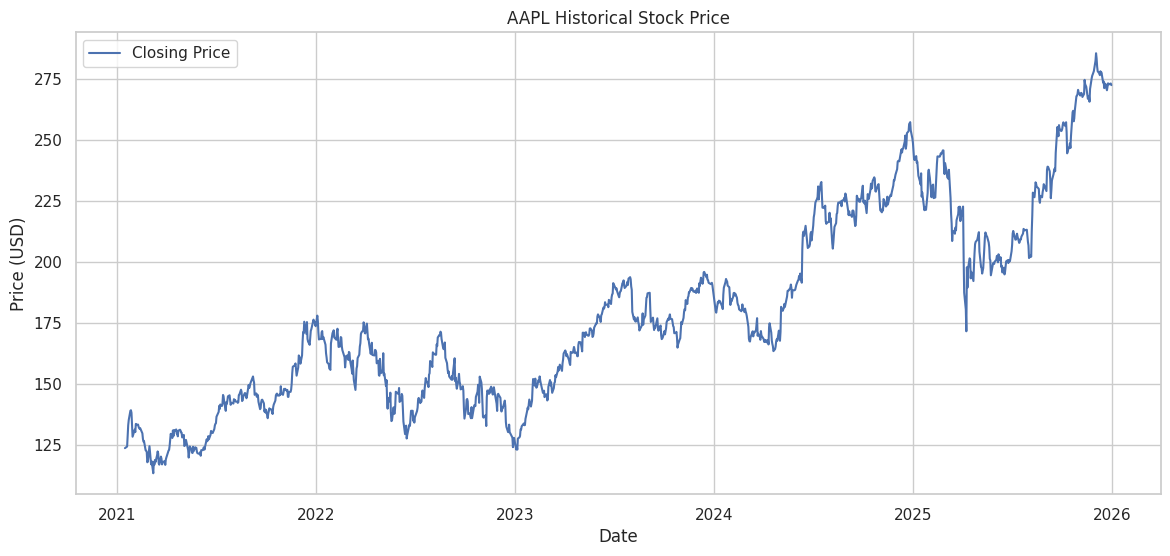

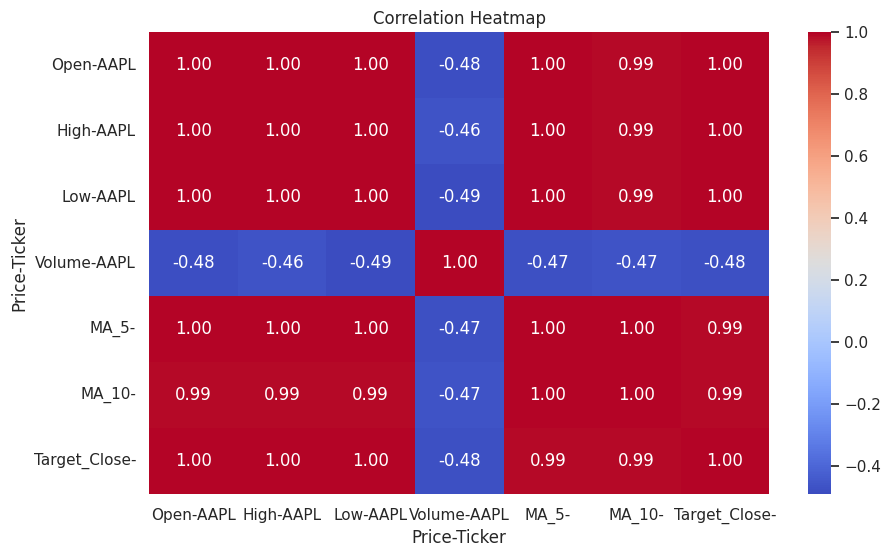

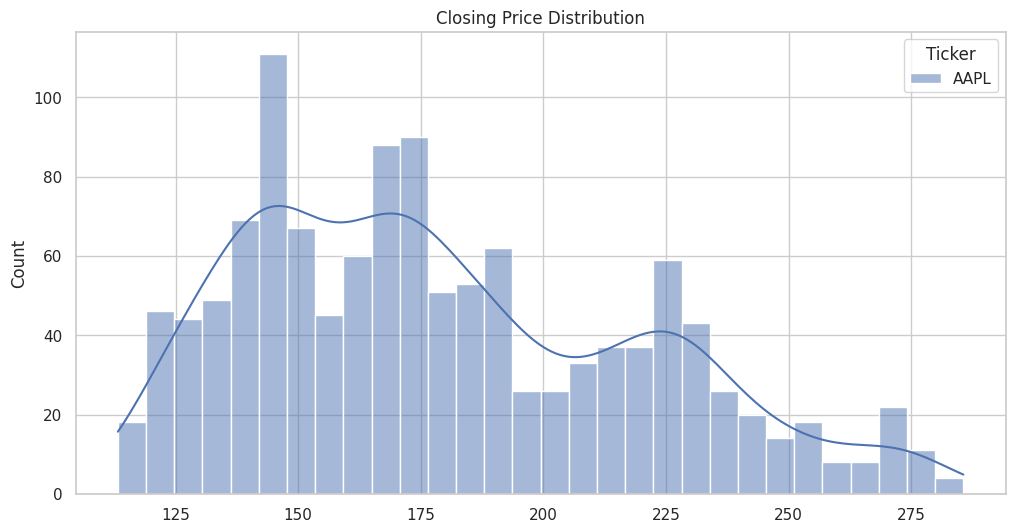


Splitting Dataset...
Training Samples: 996
Testing Samples: 249

Training Random Forest Model...
Model Training Completed

Performance Metrics
MAE : 7.75
RMSE : 10.67
R² Score : 0.8388


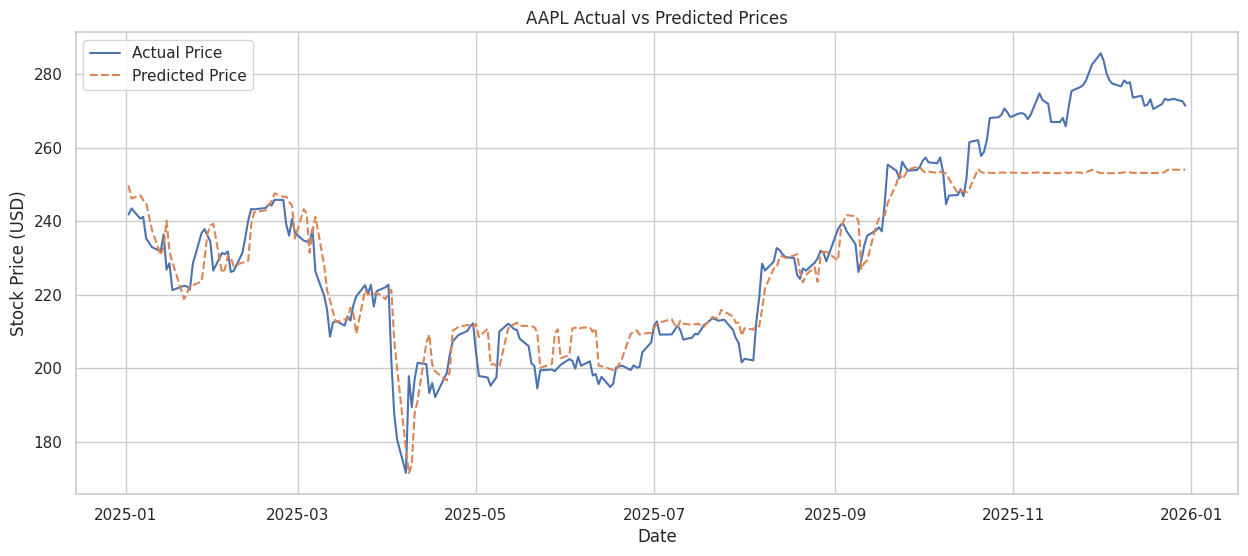


Feature Importance:
  Feature  Importance
2     Low    0.730024
1    High    0.191941
4    MA_5    0.046968
0    Open    0.021353
5   MA_10    0.008186
3  Volume    0.001528


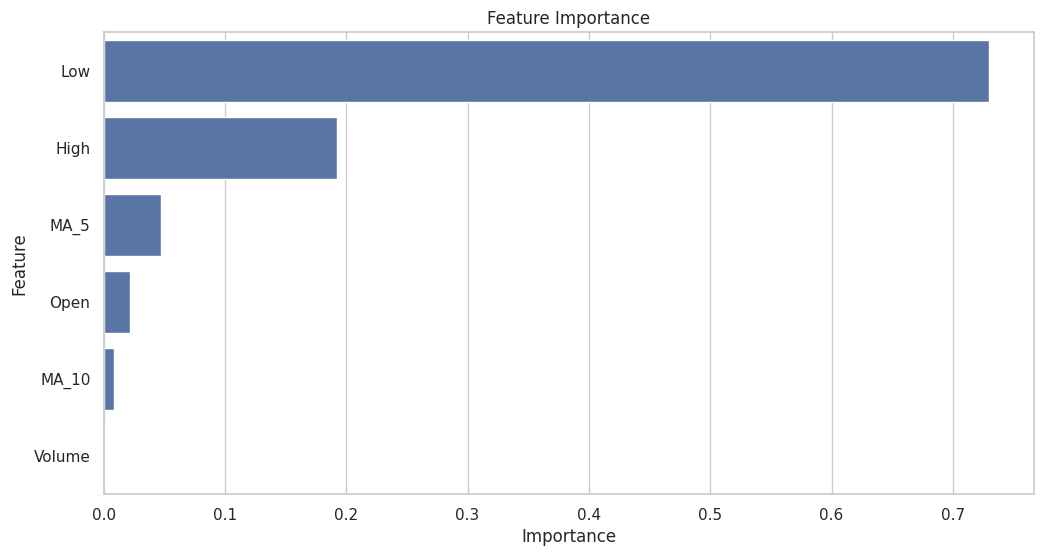


Final Insights:

1. Random Forest captured stock patterns using historical features.

2. Moving averages (MA_5 and MA_10) improved prediction quality.

3. The model predicted short-term stock movements reasonably well.

4. Feature importance shows which variables influence prediction the most.

5. Prediction accuracy can be further improved using:
   - LSTM models
   - Additional technical indicators
   - More historical data



In [4]:
# =====================================================================
# DevelopersHub Corporation - AI/ML Engineering Internship
# Task 2: Short-Term Stock Price Prediction
# Objective: Predict next-day closing stock price using yfinance data
# =====================================================================

# -------------------------------
# Import Libraries
# -------------------------------

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# -------------------------------
# 1. Fetch Historical Stock Data
# -------------------------------

print("Fetching Stock Data..")

ticker_symbol = "AAPL"     # Apple stock
start_date = "2021-01-01"
end_date = "2026-01-01"

df = yf.download(
    ticker_symbol,
    start=start_date,
    end=end_date
)

print("\nData Loaded Successfully")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


# -------------------------------
# 2. Data Preprocessing
# -------------------------------

print("\nPreprocessing Data...")

# Remove missing values
df = df.dropna()

# Create moving average features
df['MA_5'] = df['Close'].rolling(5).mean()

df['MA_10'] = df['Close'].rolling(10).mean()

# Create next day target
df['Target_Close'] = df['Close'].shift(-1)

# Remove missing rows created by rolling and shifting
df = df.dropna()

print("Feature Engineering Complete")


# -------------------------------
# 3. Feature Selection
# -------------------------------

features = [
    'Open',
    'High',
    'Low',
    'Volume',
    'MA_5',
    'MA_10'
]

X = df[features]
y = df['Target_Close']


# -------------------------------
# 4. Exploratory Data Analysis
# -------------------------------

print("\nGenerating Visualizations...")

# Historical Close Price

plt.figure(figsize=(14,6))
plt.plot(
    df.index,
    df['Close'],
    label='Closing Price'
)

plt.title(
    f'{ticker_symbol} Historical Stock Price'
)

plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    df[features+['Target_Close']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()


# Distribution plot

plt.figure()

sns.histplot(
    df['Close'],
    bins=30,
    kde=True
)

plt.title("Closing Price Distribution")
plt.show()


# -------------------------------
# 5. Train Test Split
# -------------------------------

print("\nSplitting Dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))


# -------------------------------
# 6. Train Random Forest Model
# -------------------------------

print("\nTraining Random Forest Model...")

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model Training Completed")


# -------------------------------
# 7. Prediction
# -------------------------------

y_pred = model.predict(X_test)


# -------------------------------
# 8. Model Evaluation
# -------------------------------

print("\nPerformance Metrics")

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")


# -------------------------------
# 9. Actual vs Predicted Plot
# -------------------------------

test_dates = df.index[-len(y_test):]

plt.figure(figsize=(15,6))

plt.plot(
    test_dates,
    y_test.values,
    label='Actual Price'
)

plt.plot(
    test_dates,
    y_pred,
    '--',
    label='Predicted Price'
)

plt.title(
    f'{ticker_symbol} Actual vs Predicted Prices'
)

plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()

plt.show()


# -------------------------------
# 10. Feature Importance
# -------------------------------

importance = pd.DataFrame({
    'Feature':features,
    'Importance':model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure()

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title(
    "Feature Importance"
)

plt.show()


# -------------------------------
# 11. Final Insights
# -------------------------------

print("\nFinal Insights:")
print("""
1. Random Forest captured stock patterns using historical features.

2. Moving averages (MA_5 and MA_10) improved prediction quality.

3. The model predicted short-term stock movements reasonably well.

4. Feature importance shows which variables influence prediction the most.

5. Prediction accuracy can be further improved using:
   - LSTM models
   - Additional technical indicators
   - More historical data
""")